In [85]:
!pip install numpy --upgrade

Defaulting to user installation because normal site-packages is not writeable
  Using cached numpy-2.2.6-cp310-cp310-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (16.8 MB)
  Attempting uninstall: numpy
    Found existing installation: numpy 1.26.4
    Uninstalling numpy-1.26.4:
      Successfully uninstalled numpy-1.26.4


In [86]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

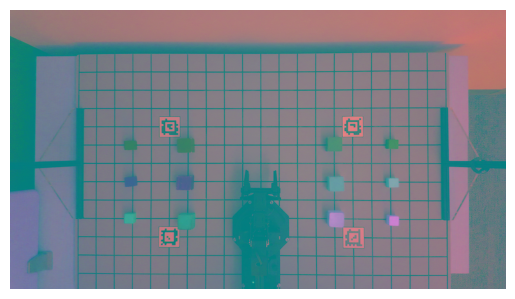

In [9]:
img = cv2.imread('/home/rob550-student-pm/armlab-w-26/src/image_all_blocks.png')

img = cv2.cvtColor(img, cv2.COLOR_BGR2LAB)

plt.imshow(img)
plt.axis('off') # Hide the x and y axis pixel coordinates
plt.show()

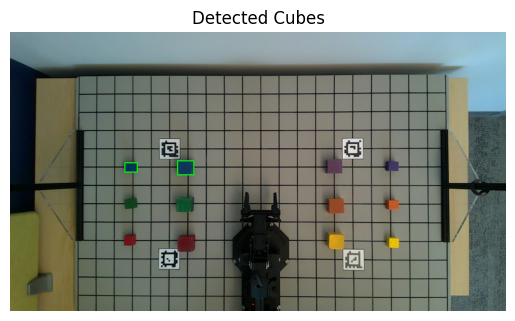

In [4]:
# 1. Load and convert
img = cv2.imread('/home/rob550-student-pm/armlab-w-26/src/image_all_blocks.png')
hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)

# 2. Define color range (Example: Blue)
# Adjust these values based on your specific lighting!
lower_blue = np.array([100, 150, 50])
upper_blue = np.array([140, 255, 255])

# 3. Create the mask
mask = cv2.inRange(hsv, lower_blue, upper_blue)

# 4. Optional: Clean up noise (erosion/dilation)
kernel = np.ones((5,5), np.uint8)
mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN, kernel)

# 5. Find the cubes
contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

# Draw a box around every blue thing found
for cnt in contours:
    if cv2.contourArea(cnt) > 500: # Filter out tiny noise
        x, y, w, h = cv2.boundingRect(cnt)
        cv2.rectangle(img, (x, y), (x+w, y+h), (0, 255, 0), 2)

# Display result
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.title("Detected Cubes")
plt.axis('off')
plt.show()

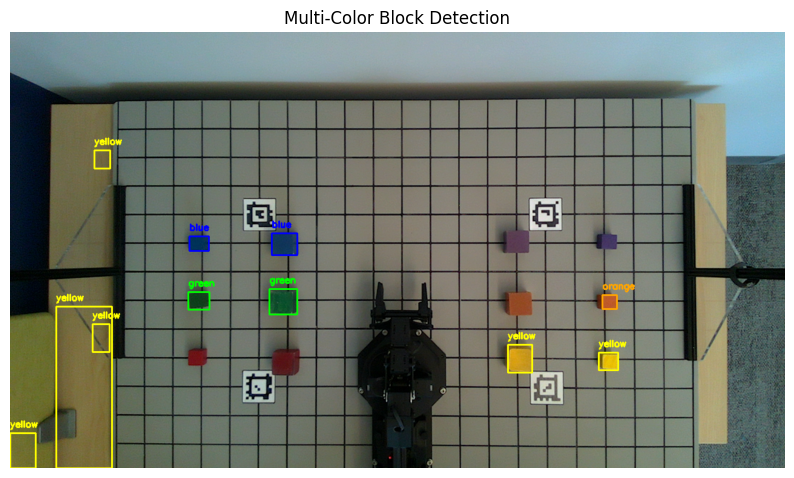

In [ ]:

# 1. Load image
img = cv2.imread('/home/rob550-student-pm/armlab-w-26/src/image_all_blocks.png')
hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)
output = img.copy()

# 2. Define HSV ranges for each color
# Format: { 'color_name': (lower_bound, upper_bound, BGR_draw_color) }
color_ranges = {
'orange': ([10, 120, 100],  [22, 255, 255],  (0, 165, 255)),
        'yellow': ([23, 120, 100],  [35, 255, 255],  (0, 255, 255)),
        'green':  ([40, 80, 50],    [90, 255, 255],  (0, 255, 0)),
        'blue':   ([100, 100, 50],  [130, 255, 255], (255, 0, 0)),
        'purple': ([135, 80, 50],   [165, 255, 255], (255, 0, 255)),
}

# 3. Special handling for Red (it wraps around)
lower_red1, upper_red1 = np.array([0, 150, 50]),   np.array([10, 255, 255])
lower_red2, upper_red2 = np.array([170, 150, 50]), np.array([180, 255, 255])

# 4. Loop through and detect
for color_name, (lower, upper, draw_color) in color_ranges.items():
    # Create mask for standard colors
    mask = cv2.inRange(hsv, lower, upper)
    
    # Add red logic specifically
    if color_name == 'red':
        mask1 = cv2.inRange(hsv, lower_red1, upper_red1)
        mask2 = cv2.inRange(hsv, lower_red2, upper_red2)
        mask = cv2.bitwise_or(mask1, mask2)

    # Clean up the mask (remove small noise)
    mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN, np.ones((5,5), np.uint8))

    # Find and draw contours
    contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    
    for cnt in contours:
        if cv2.contourArea(cnt) > 400: # Ignore tiny specks
            x, y, w, h = cv2.boundingRect(cnt)
            # Draw the box
            cv2.rectangle(output, (x, y), (x + w, y + h), draw_color, 2)
            # Label it
            cv2.putText(output, color_name, (x, y - 10), 
                        cv2.FONT_HERSHEY_SIMPLEX, 0.5, draw_color, 2)

# 5. Show the final result
plt.figure(figsize=(10, 8))
plt.imshow(cv2.cvtColor(output, cv2.COLOR_BGR2RGB))
plt.axis('off')
plt.title("Multi-Color Block Detection")
plt.show()

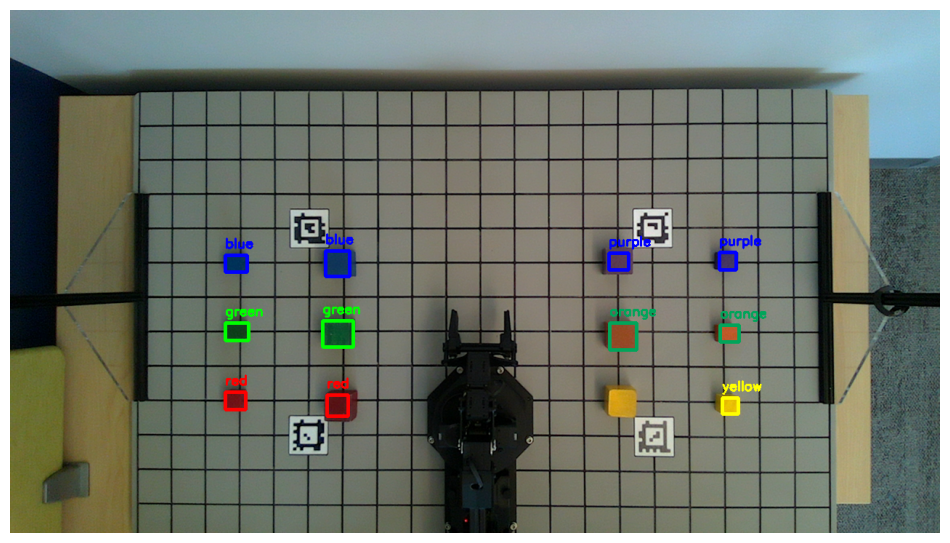

In [24]:

# 1. Load the image
img = cv2.imread('/home/rob550-student-pm/armlab-w-26/src/image_all_blocks.png')
if img is None:
    print("Error: Could not find the image path.")
else:
    hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)
    output = img.copy()

    # 2. Refined HSV Ranges for your specific blocks
    # Note: Red is handled separately below due to the 180-0 wrap-around

    # H - 0-180
    # S - 0-255
    # V - 0-255

    # given
    # H - 0-360
    # S - 0-100 (%)
    # V - 0-100 (%)

    # GIVEN 
    # red = (350-360, 0-15), (70 - 85)%, (30 - 45)%
    # orange = (15-25), (75-85)% , (50 - 80)%
    # yellow = (40-50), (80-100)%, (85-100)%
    # green = (120-155), (55 - 80)%, (20 - 40)%
    # blue = (200-230), (75-100)%, (30 - 45)%
    # purple = (255-320), (30 - 60), (20 - 40)%


    # web2here
    web2here = np.array([[0.5, 255/100, 255/100], [0.5, 255/100, 255/100], [1, 1, 1]])

    # 3. red wrapping (hsv) (Two ranges merged)
    lower_red1, upper_red1 = np.array([0, 70, 30]) * web2here[0],   np.array([15, 100, 45]) * web2here[0]
    lower_red2, upper_red2 = np.array([350, 70, 30]) * web2here[0], np.array([360, 100, 45]) * web2here[0]


    color_ranges = {
        'orange': ([15, 60, 50],  [35, 90, 100],  (90, 165, 0))     * web2here,
        'yellow': ([40, 80, 85],  [50, 100, 100],  (0, 255, 255))   * web2here,
        'green':  ([120, 55, 10],    [165, 95, 50],  (0, 255, 0))   * web2here,
        'blue':   ([180, 75, 30],  [230, 100, 45], (255, 0, 0))     * web2here,
        'purple': ([235, 30, 20],   [320, 60, 40], (255, 0, 0))     * web2here,
    }

    # color_ranges = {
    #     'orange': ([10, 120, 100],  [22, 255, 255],  (0, 165, 255)),
    #     'yellow': ([23, 120, 100],  [35, 255, 255],  (0, 255, 255)),
    #     'green':  ([40, 80, 50],    [90, 255, 255],  (0, 255, 0)),
    #     'blue':   ([100, 100, 50],  [130, 255, 255], (255, 0, 0)),
    #     'purple': ([135, 80, 50],   [165, 255, 255], (255, 0, 255)),
    # }

    # 3. Special handling for Red (Two ranges merged)
    # lower_red1, upper_red1 = np.array([0, 120, 100]),   np.array([10, 255, 255])
    # lower_red2, upper_red2 = np.array([170, 120, 100]), np.array([180, 255, 255])

    # 4. Loop through colors
    for name, (low, high, bgr_color) in color_ranges.items():
        mask = cv2.inRange(hsv, np.array(low), np.array(high))
        
        # Clean the mask: Remove small dots and bridge small gaps in the blocks
        kernel = np.ones((5,5), np.uint8)
        mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN, kernel) 
        mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel)

        # Find blocks
        contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
        for cnt in contours:
            if cv2.contourArea(cnt) > 300: # Adjust if tiny blocks are missed
                x, y, w, h = cv2.boundingRect(cnt)
                cv2.rectangle(output, (x, y), (x+w, y+h), bgr_color, 3)
                cv2.putText(output, name, (x, y-10), cv2.FONT_HERSHEY_SIMPLEX, 0.6, bgr_color, 2)

    # 5. Handle Red specifically
    red_mask = cv2.bitwise_or(cv2.inRange(hsv, lower_red1, upper_red1), 
                              cv2.inRange(hsv, lower_red2, upper_red2))
    red_mask = cv2.morphologyEx(red_mask, cv2.MORPH_OPEN, kernel)
    contours, _ = cv2.findContours(red_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    for cnt in contours:
        if cv2.contourArea(cnt) > 300:
            x, y, w, h = cv2.boundingRect(cnt)
            cv2.rectangle(output, (x, y), (x+w, y+h), (0, 0, 255), 3)
            cv2.putText(output, 'red', (x, y-10), cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0, 0, 255), 2)

    # 6. Display
    plt.figure(figsize=(12, 8))
    plt.imshow(cv2.cvtColor(output, cv2.COLOR_BGR2RGB))
    plt.axis('off')
    plt.show()


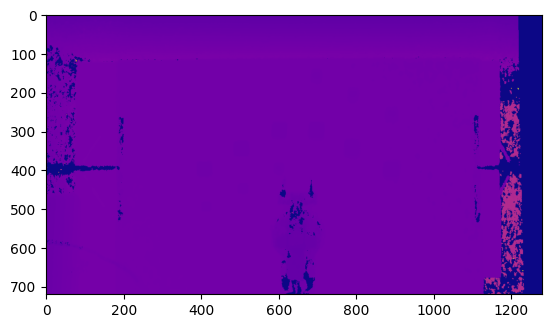

In [79]:
img = plt.imread('/home/rob550-student-pm/armlab-w-26/src/depth_blocks.png')

plt.imshow(img, cmap='plasma')

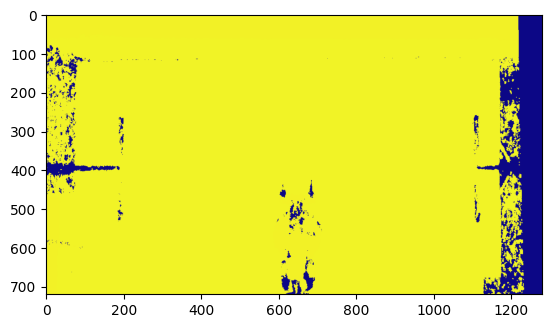

In [83]:
img.min(), img.max()

img = np.power(img, 0.1)

plt.imshow(img, cmap='plasma')

In [81]:
img.min(), img.max()

(0.0, 0.7645788)

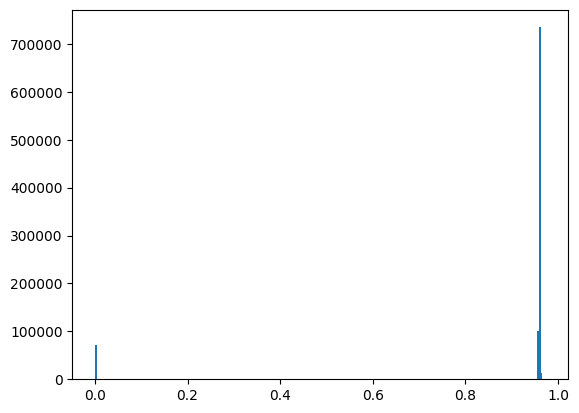

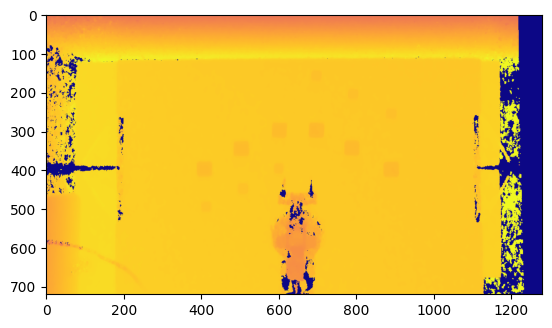

In [84]:
np.shape(img)


img_straight = img.flatten()
a = plt.hist(img_straight, bins=256)

plt.show(a)

img_clipped = np.clip(img, 0.95, 0.96)
plt.imshow(img_clipped, cmap='plasma')



In [104]:
img.shape

(720, 1280, 3)

In [105]:
img[0, 0]

array([151, 142, 110], dtype=uint8)

In [108]:
x, y, z = img.shape 

for i in range(x):
    for j in range(y):
        img[i, j] = img[i, j] / (np.mean(img[i, j])) * 255

/tmp/ipykernel_117302/1413083075.py:5: RuntimeWarning: invalid value encountered in divide
  img[i, j] = img[i, j] / (np.mean(img[i, j])) * 255
/tmp/ipykernel_117302/1413083075.py:5: RuntimeWarning: invalid value encountered in cast
  img[i, j] = img[i, j] / (np.mean(img[i, j])) * 255


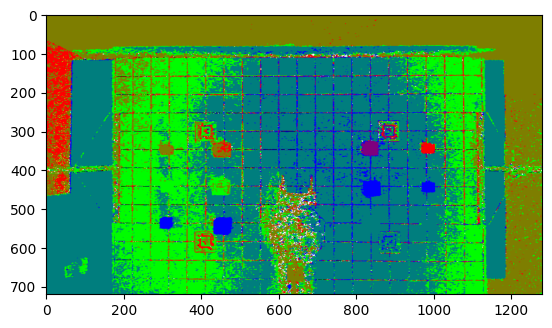

In [109]:
truth_image = img.copy()
plt.imshow(truth_image)

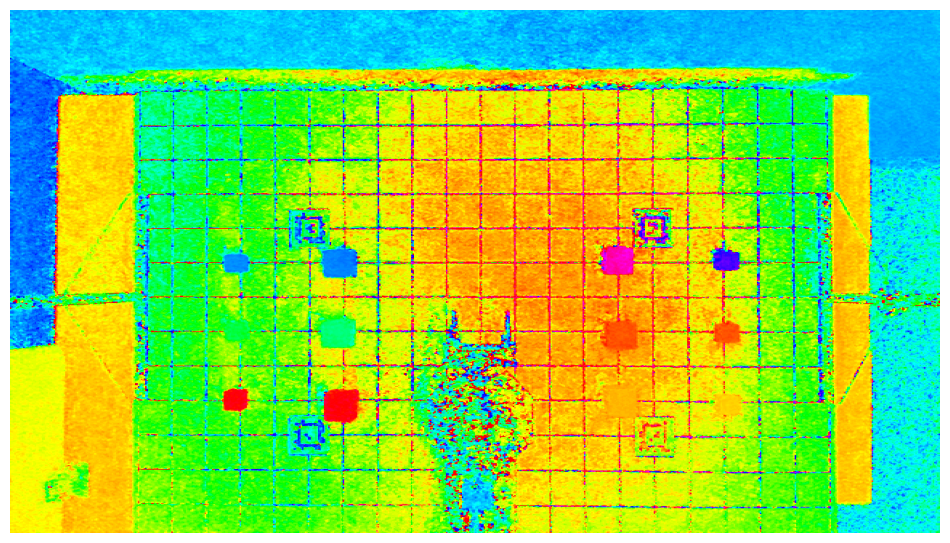

In [ ]:

# 1. Load the image
img = cv2.imread('/home/rob550-student-pm/armlab-w-26/src/image_all_blocks.png')
if img is None:
    print("Error: Could not find the image path.")
else:
    # hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)
    output = img.copy()

    


    # web2here
    web2here = np.array([[0.5, 255/100, 255/100], [0.5, 255/100, 255/100], [1, 1, 1]])

    # 3. red wrapping (hsv) (Two ranges merged)
    lower_red1, upper_red1 = np.array([0, 70, 30]) * web2here[0],   np.array([15, 100, 45]) * web2here[0]
    lower_red2, upper_red2 = np.array([350, 70, 30]) * web2here[0], np.array([360, 100, 45]) * web2here[0]


    color_ranges = {
        'orange': ([15, 60, 50],  [35, 90, 100],  (90, 165, 0))     * web2here,
        'yellow': ([40, 80, 85],  [50, 100, 100],  (0, 255, 255))   * web2here,
        'green':  ([120, 55, 10],    [165, 95, 50],  (0, 255, 0))   * web2here,
        'blue':   ([180, 75, 30],  [230, 100, 45], (255, 0, 0))     * web2here,
        'purple': ([235, 30, 20],   [320, 60, 40], (255, 0, 0))     * web2here,
    }


    # 4. Loop through colors
    for name, (low, high, bgr_color) in color_ranges.items():
        mask = cv2.inRange(hsv, np.array(low), np.array(high))
        
        # Clean the mask: Remove small dots and bridge small gaps in the blocks
        kernel = np.ones((5,5), np.uint8)
        mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN, kernel) 
        mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel)

        # Find blocks
        contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
        for cnt in contours:
            if cv2.contourArea(cnt) > 300: # Adjust if tiny blocks are missed
                x, y, w, h = cv2.boundingRect(cnt)
                cv2.rectangle(output, (x, y), (x+w, y+h), bgr_color, 3)
                cv2.putText(output, name, (x, y-10), cv2.FONT_HERSHEY_SIMPLEX, 0.6, bgr_color, 2)

    # 5. Handle Red specifically
    red_mask = cv2.bitwise_or(cv2.inRange(hsv, lower_red1, upper_red1), 
                              cv2.inRange(hsv, lower_red2, upper_red2))
    red_mask = cv2.morphologyEx(red_mask, cv2.MORPH_OPEN, kernel)
    contours, _ = cv2.findContours(red_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    for cnt in contours:
        if cv2.contourArea(cnt) > 300:
            x, y, w, h = cv2.boundingRect(cnt)
            cv2.rectangle(output, (x, y), (x+w, y+h), (0, 0, 255), 3)
            cv2.putText(output, 'red', (x, y-10), cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0, 0, 255), 2)

    # 6. Display
    plt.figure(figsize=(12, 8))
    plt.imshow(cv2.cvtColor(hsv, cv2.COLOR_HSV2RGB))
    plt.axis('off')
    plt.show()
